In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import pickle
import gensim
from gensim.models import Word2Vec
import numpy as np

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"  # Use raw string to handle Windows file paths
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
# Assuming 'cleaned_text' contains space-separated words
tokenized_texts = [text.split() for text in data[text_column]]  # Tokenize the text into words

# Step 2: Train the Word2Vec model
print("Training Word2Vec model...")
word2vec_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=1, workers=4)
word2vec_model.save(r"C:\Users\PC\Downloads\word2vec_model.model")  # Optionally save the model

# Step 3: Generate word embeddings for each document
def get_word2vec_embeddings(text, model, vector_size=100):
    embeddings = np.zeros(vector_size)
    count = 0
    for word in text:
        if word in model.wv:
            embeddings += model.wv[word]
            count += 1
    if count > 0:
        embeddings /= count  # Average the embeddings
    return embeddings

# Apply the word2vec embeddings to each document
X_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in tokenized_texts])

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_word2vec, data[target_column], test_size=0.2, random_state=42)

# Step 5: Initialize and train the XGBoost model
print("Training XGBoost Model...")
dtrain = xgb.DMatrix(X_train, label=y_train)  # Convert data to DMatrix format for XGBoost
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'multi:softmax',  # For multi-class classification
    'eval_metric': 'mlogloss',      # Log loss metric for multi-class classification
    'num_class': len(y_train.unique()),  # Number of classes
    'max_depth': 6,                 # Maximum depth of the trees
    'learning_rate': 0.1,           # Step size shrinkage
    'subsample': 0.8,               # Fraction of data to train on
    'colsample_bytree': 0.8,        # Fraction of features for each tree
    'nthread': 4                    # Number of threads for parallelism
}

# Train the model
num_round = 100  # Number of boosting rounds
xgb_model = xgb.train(params, dtrain, num_round)

# Step 6: Save the trained XGBoost model
model_path = r"C:\Users\PC\Downloads\xgboost_model_word2vec.pkl"  # File path to save the model
with open(model_path, 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"Trained XGBoost model saved to {model_path}")

# Step 7: Evaluate the XGBoost model
y_pred_xgb = xgb_model.predict(dtest)

# Print accuracy, precision, recall, F1 score, and classification report
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average='weighted')  # Weighted for multi-class
recall = recall_score(y_test, y_pred_xgb, average='weighted')  # Weighted for multi-class
f1 = f1_score(y_test, y_pred_xgb, average='weighted')  # Weighted for multi-class

print(f"XGBoost Accuracy: {accuracy * 100:.2f}%")
print(f"XGBoost Precision: {precision * 100:.2f}%")
print(f"XGBoost Recall: {recall * 100:.2f}%")
print(f"XGBoost F1 Score: {f1 * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


Training Word2Vec model...
Training XGBoost Model...
Trained XGBoost model saved to C:\Users\PC\Downloads\xgboost_model_word2vec.pkl
XGBoost Accuracy: 92.70%
XGBoost Precision: 92.71%
XGBoost Recall: 92.70%
XGBoost F1 Score: 92.70%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93     23238
           1       0.92      0.93      0.93     23171

    accuracy                           0.93     46409
   macro avg       0.93      0.93      0.93     46409
weighted avg       0.93      0.93      0.93     46409



Training Word2Vec model...
Training XGBoost Model...
Trained XGBoost model saved to C:\Users\PC\Downloads\xgboost_model_word2vec.pkl


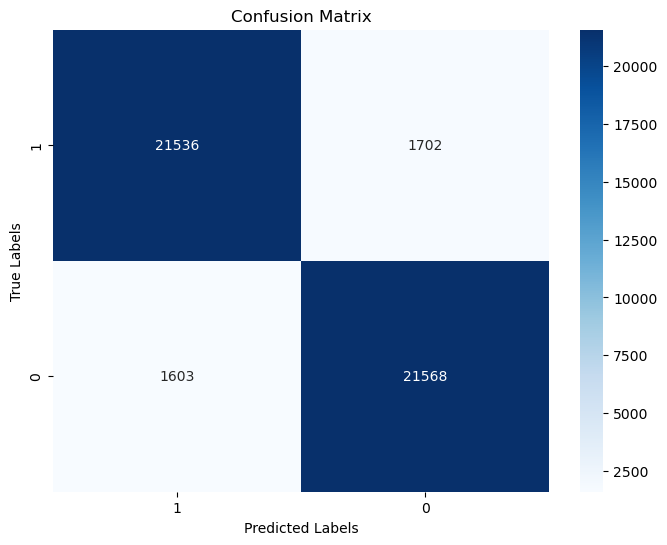

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import pickle
import gensim
from gensim.models import Word2Vec
import numpy as np

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"  # Use raw string to handle Windows file paths
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
# Assuming 'cleaned_text' contains space-separated words
tokenized_texts = [text.split() for text in data[text_column]]  # Tokenize the text into words

# Step 2: Train the Word2Vec model
print("Training Word2Vec model...")
word2vec_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=1, workers=4)
word2vec_model.save(r"C:\Users\PC\Downloads\word2vec_model.model")  # Optionally save the model

# Step 3: Generate word embeddings for each document
def get_word2vec_embeddings(text, model, vector_size=100):
    embeddings = np.zeros(vector_size)
    count = 0
    for word in text:
        if word in model.wv:
            embeddings += model.wv[word]
            count += 1
    if count > 0:
        embeddings /= count  # Average the embeddings
    return embeddings

# Apply the word2vec embeddings to each document
X_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in tokenized_texts])

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_word2vec, data[target_column], test_size=0.2, random_state=42)

# Step 5: Initialize and train the XGBoost model
print("Training XGBoost Model...")
dtrain = xgb.DMatrix(X_train, label=y_train)  # Convert data to DMatrix format for XGBoost
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'multi:softmax',  # For multi-class classification
    'eval_metric': 'mlogloss',      # Log loss metric for multi-class classification
    'num_class': len(y_train.unique()),  # Number of classes
    'max_depth': 6,                 # Maximum depth of the trees
    'learning_rate': 0.1,           # Step size shrinkage
    'subsample': 0.8,               # Fraction of data to train on
    'colsample_bytree': 0.8,        # Fraction of features for each tree
    'nthread': 4                    # Number of threads for parallelism
}

# Train the model
num_round = 100  # Number of boosting rounds
xgb_model = xgb.train(params, dtrain, num_round)

# Step 6: Save the trained XGBoost model
model_path = r"C:\Users\PC\Downloads\xgboost_model_word2vec.pkl"  # File path to save the model
with open(model_path, 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"Trained XGBoost model saved to {model_path}")
# Step 7: Evaluate the XGBoost model
y_pred_xgb = xgb_model.predict(dtest)  # This should already return the predicted class labels

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plotting the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data[target_column].unique(), yticklabels=data[target_column].unique())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


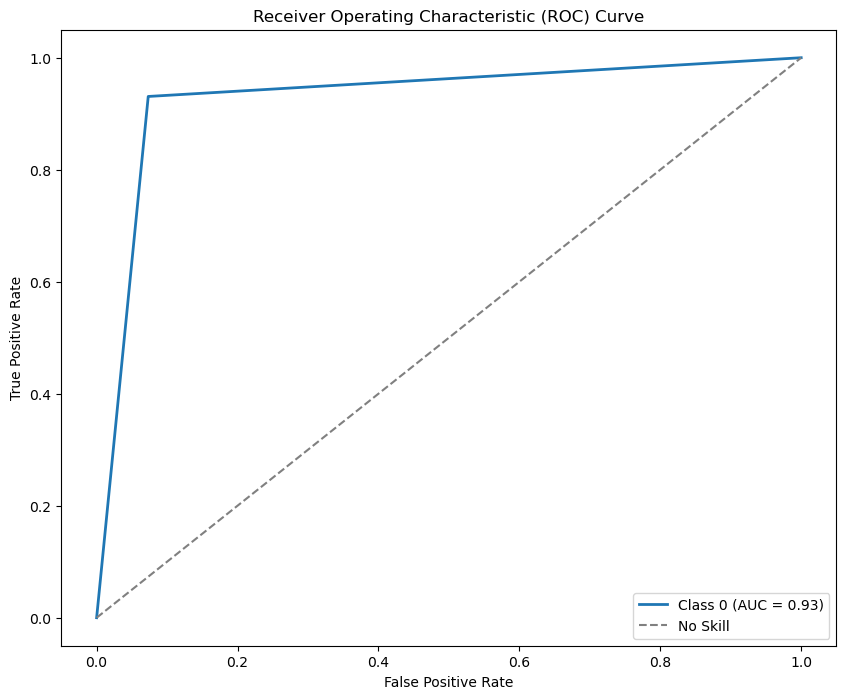

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 8: Get the predicted probabilities (needed for ROC curve, not the class labels)
y_pred_proba = xgb_model.predict(dtest, output_margin=False)  # Get predicted probabilities

# If it's a multi-class problem, ensure the shape is (num_samples, num_classes)
if y_pred_proba.ndim == 1:
    y_pred_proba = np.expand_dims(y_pred_proba, axis=1)

# Convert the true labels to binary format (one-hot encoding) for multi-class ROC
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# Step 9: Plot ROC curve for each class
n_classes = y_test_bin.shape[1]
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot ROC curve for the "no skill" classifier (diagonal line)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='No Skill')

# Customize plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


XGBoost MAE: 0.0712, MSE: 0.0712, RMSE: 0.2669


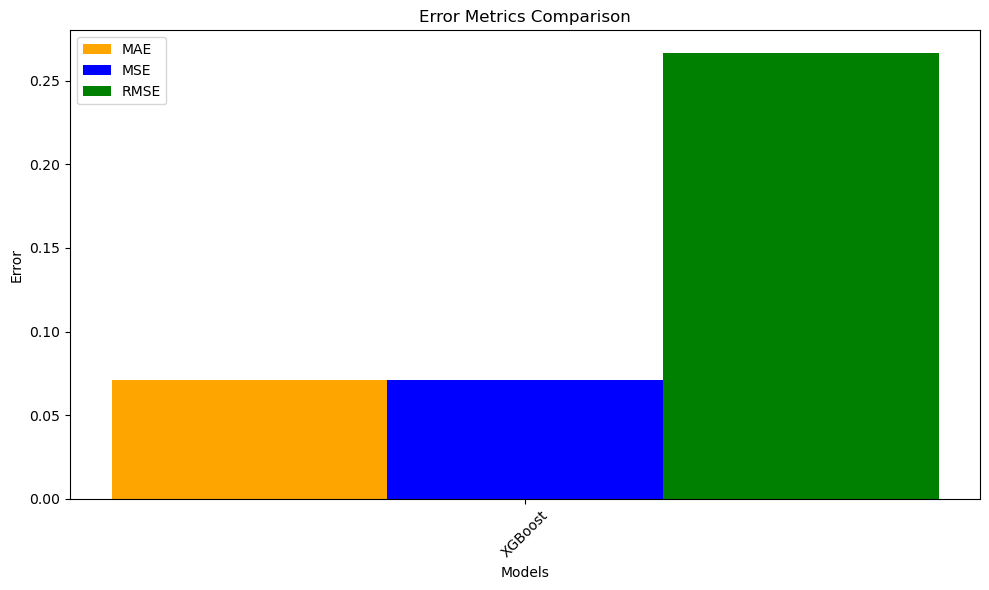

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Dictionary to store error metrics
error_metrics = {}

# For the XGBoost model (assuming it's already trained and available)
model_name = "XGBoost"  # You can change this if you have multiple models

# Predict on the test set
y_pred_xgb = xgb_model.predict(dtest)

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)

# Store error metrics
error_metrics[model_name] = {"MAE": mae, "MSE": mse, "RMSE": rmse}

# Print metrics for the current model
print(f"{model_name} MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

# Plot the error metrics for comparison
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

# Creating the bar plot
x = np.arange(len(model_names))  # x positions for each model
width = 0.25  # Bar width

plt.figure(figsize=(10, 6))
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()


C:\Users\PC\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:16:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\PC\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:16:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\PC\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:16:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\PC\anaconda3\Lib\site-packages\xgboost\core

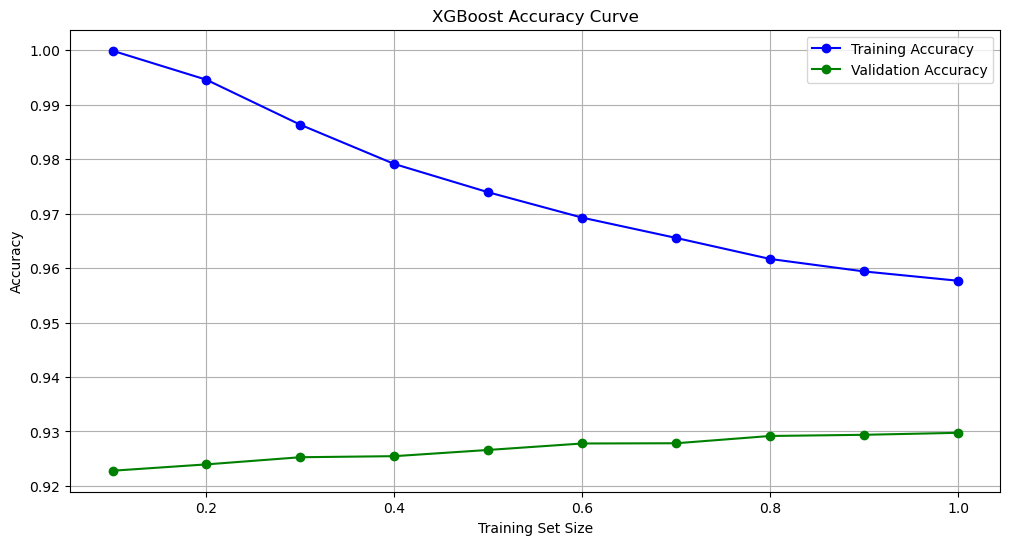

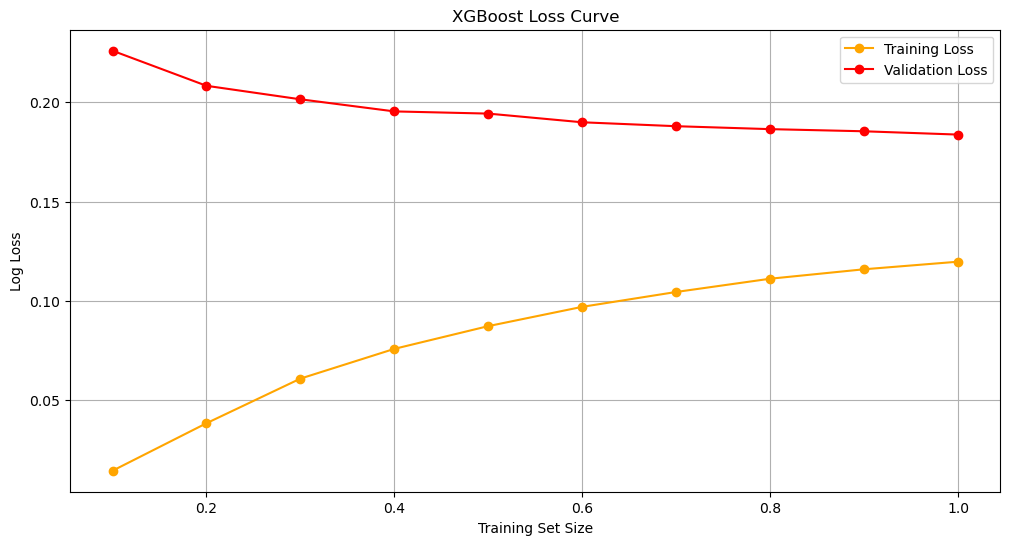

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, accuracy_score
import xgboost as xgb

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Arrays to store accuracy and loss
train_sizes = np.linspace(0.1, 1.0, 10)  # Progressively larger portions of the training data
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

# Loop through different training data sizes
for size in train_sizes:
    # Use a portion of the training data
    subset_size = int(size * len(X_train))
    X_train_subset = X_train[:subset_size]
    y_train_subset = y_train[:subset_size]
    
    # Train the model on the subset
    xgb_model.fit(X_train_subset, y_train_subset)
    
    # Predict on the training subset and validation set
    y_train_pred = xgb_model.predict(X_train_subset)
    y_val_pred = xgb_model.predict(X_test)
    
    # Predict probabilities for loss calculation
    y_train_proba = xgb_model.predict_proba(X_train_subset)
    y_val_proba = xgb_model.predict_proba(X_test)
    
    # Calculate accuracy
    train_accuracies.append(accuracy_score(y_train_subset, y_train_pred))
    val_accuracies.append(accuracy_score(y_test, y_val_pred))
    
    # Calculate log loss
    train_losses.append(log_loss(y_train_subset, y_train_proba))
    val_losses.append(log_loss(y_test, y_val_proba))

# Plot Accuracy Curve
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(train_sizes, val_accuracies, label='Validation Accuracy', marker='o', color='green')
plt.title('XGBoost Accuracy Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid()
plt.show()

# Plot Loss Curve
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_losses, label='Training Loss', marker='o', color='orange')
plt.plot(train_sizes, val_losses, label='Validation Loss', marker='o', color='red')
plt.title('XGBoost Loss Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.legend(loc='best')
plt.grid()
plt.show()
